# 📈 Logistic Regression Trading Strategy: Beating Buy-the-Dip
## Stocks: NVDA & MSFT | Hold Period: 1 Week – 1 Month

This notebook builds a **multi-signal logistic regression trading strategy** using:
- 🔧 Technical Indicators (RSI, MACD, Bollinger Bands, Moving Averages)
- 📊 Fundamental Indicators (P/E ratio, EPS growth, Revenue)
- 💬 Sentiment Analysis (News sentiment scoring)
- 🚀 Momentum Indicators (Rate of Change, Price Momentum)
- 🌍 Macroeconomic & Geopolitical Variables (Interest Rates, VIX, DXY, Inflation)

**Goal:** Generate Buy/Sell signals via Logistic Regression and backtest against a naive Buy-the-Dip baseline.

## 1. Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics used later in notebook reports
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Modular strategy helpers
from strategy_lib.config import FEATURE_COLS
from strategy_lib.data import fetch_ohlcv, fetch_fundamentals
from strategy_lib.features import (
    add_technical_indicators,
    fetch_ibkr_news_sentiment,
    add_sentiment_features,
    add_momentum_features,
    build_macro_enhanced,
)
from strategy_lib.modeling import build_all_ml_datasets, train_all_models, generate_signal_series
from strategy_lib.backtest import backtest_one_ticker

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ All libraries imported successfully!")
print(f"📅 Analysis Date: {datetime.today().strftime('%Y-%m-%d')}")

✅ All libraries imported successfully!
📅 Analysis Date: 2026-03-04


## 2. Select Stock Universe & Configuration

In [2]:
# ─── Stock Universe ────────────────────────────────────────────────────────────
STOCKS = ["NVDA", "MSFT"]

# ─── Date Range ────────────────────────────────────────────────────────────────
END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=5*365)).strftime('%Y-%m-%d')

# ─── Strategy Config ───────────────────────────────────────────────────────────
HOLD_PERIODS = {
    "1W":  5,    # 1 week  in trading days
    "2W":  10,   # 2 weeks in trading days
    "1M":  21,   # 1 month in trading days
}
TARGET_HOLD = "1W"        # Primary hold period to optimise for
THRESHOLD   = 0.0025      # Min return threshold to classify as "Buy" (25bps)

# ─── Macro Tickers ─────────────────────────────────────────────────────────────
MACRO_TICKERS = {
    "VIX":  "^VIX",        # Fear / volatility index
    "DXY":  "DX-Y.NYB",    # US Dollar index
    "TNX":  "^TNX",        # 10-Year Treasury yield
    "OIL":  "CL=F",        # Crude Oil futures
    "SPY":  "SPY",         # S&P 500 ETF (broad market)
}

print(f"📋 Stocks selected  : {STOCKS}")
print(f"📅 Date range       : {START_DATE}  →  {END_DATE}")
print(f"⏱  Hold periods     : {HOLD_PERIODS}")
print(f"🎯 Primary hold     : {TARGET_HOLD} ({HOLD_PERIODS[TARGET_HOLD]} trading days)")
print(f"📈 Buy threshold    : >{THRESHOLD*100:.2f}% forward return")

📋 Stocks selected  : ['NVDA', 'MSFT']
📅 Date range       : 2021-03-05  →  2026-03-04
⏱  Hold periods     : {'1W': 5, '2W': 10, '1M': 21}
🎯 Primary hold     : 1W (5 trading days)
📈 Buy threshold    : >0.25% forward return


## 3. Fetch Historical Stock & Macro Data

In [ ]:
# ── Stock price data ───────────────────────────────────────────────────────────
raw_stock = {}
for ticker in STOCKS:
    raw_stock[ticker] = fetch_ohlcv(ticker, START_DATE, END_DATE)
    print(f"  {ticker}: {len(raw_stock[ticker])} rows | "
          f"{raw_stock[ticker].index[0].date()} → {raw_stock[ticker].index[-1].date()}")

# ── Macro / risk-factor data ───────────────────────────────────────────────────
raw_macro = {}
print("\nFetching macro data …")
for name, ticker in MACRO_TICKERS.items():
    df = fetch_ohlcv(ticker, START_DATE, END_DATE)
    raw_macro[name] = df[['close']].rename(columns={'close': name})
    print(f"  {name} ({ticker}): {len(raw_macro[name])} rows")

# Merge macro series into a single DataFrame aligned to trading days
macro_df = pd.concat(raw_macro.values(), axis=1).ffill()
print(f"\n✅ Macro DataFrame shape: {macro_df.shape}")

# Quick sanity plot
fig, axes = plt.subplots(1, len(STOCKS), figsize=(16, 4))
for ax, ticker in zip(axes, STOCKS):
    raw_stock[ticker]['close'].plot(ax=ax, title=f"{ticker} – Close Price", color='steelblue', linewidth=1.2)
    ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)")
plt.suptitle("Historical Close Prices", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

  NVDA: 1254 rows | 2021-03-05 → 2026-03-03
  MSFT: 1254 rows | 2021-03-05 → 2026-03-03

Fetching macro data …


RuntimeError: Stooq fetch failed for ^VIX

Error 326, reqId -1: Unable to connect as the client id is already in use. Retry with a unique client id.
Peer closed connection. clientId 9 already in use?
Error 326, reqId -1: Unable to connect as the client id is already in use. Retry with a unique client id.
Peer closed connection. clientId 9 already in use?
API connection failed: TimeoutError()
API connection failed: TimeoutError()


## 4. Calculate Technical Indicators

We compute a rich set of technical signals:
| Category | Indicators |
|---|---|
| Trend | SMA(10,20,50), EMA(12,26), Price vs SMA ratio |
| Momentum | RSI(14), ROC(5,10), MACD line & signal |
| Volatility | Bollinger Band width, %B, ATR(14) |
| Volume | OBV, Volume ratio (vs 20-day avg) |

  NVDA: 28 features computed
  MSFT: 28 features computed


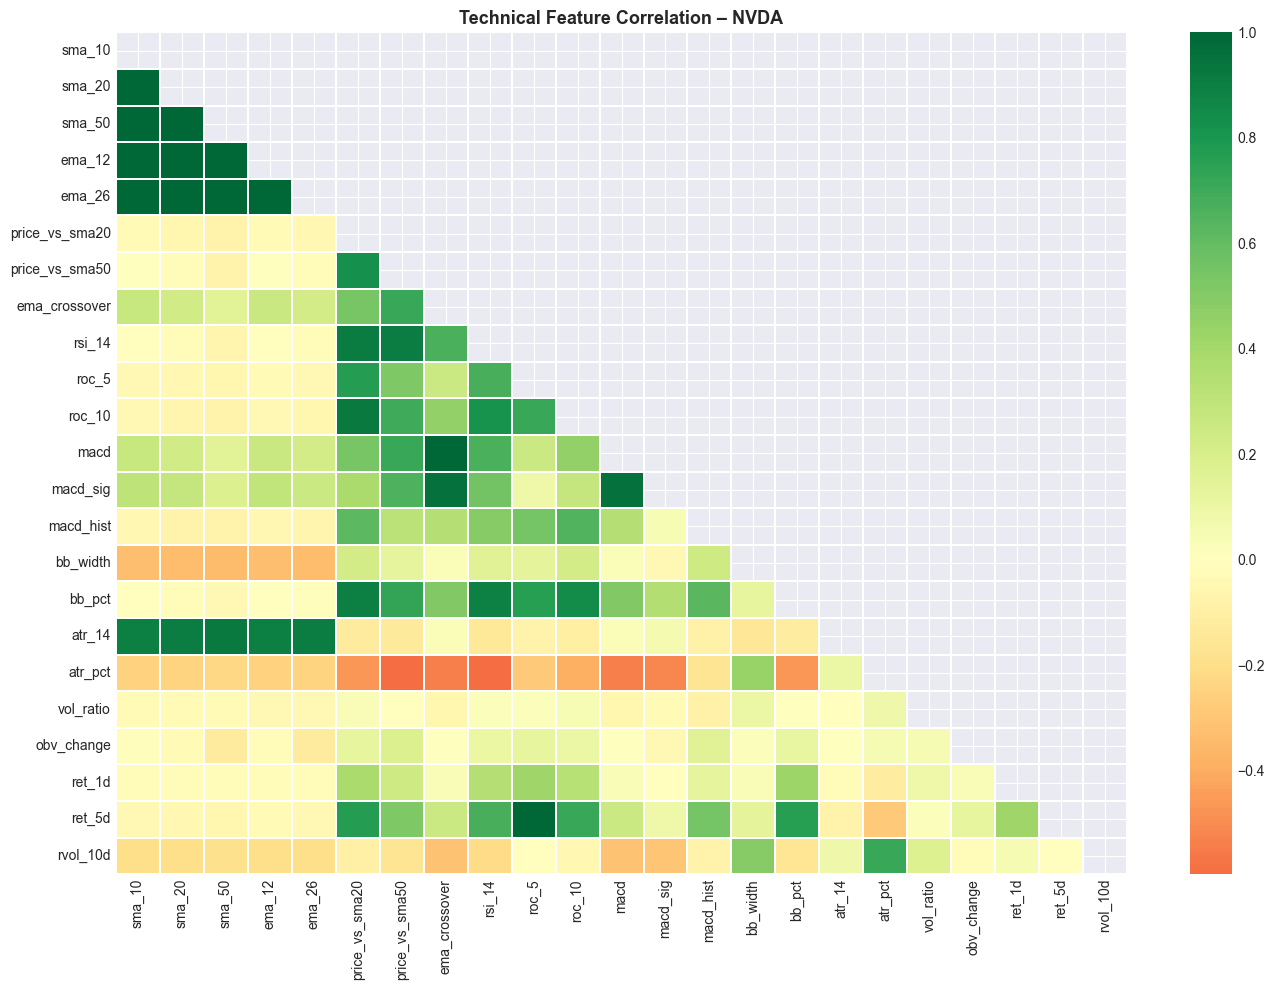

✅ Technical indicators computed for all stocks.


In [4]:
# Apply technical features via module function
tech_data = {}
for ticker in STOCKS:
    df_tech = raw_stock[ticker].copy()
    df_tech = add_technical_indicators(df_tech)
    tech_data[ticker] = df_tech
    print(f"  {ticker}: {df_tech.shape[1]} features computed")

# ── Correlation heatmap of technical features (NVDA example) ──────────────────
tech_cols = [c for c in tech_data['NVDA'].columns
             if c not in ['open','high','low','close','volume']]
corr = tech_data['NVDA'][tech_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title("Technical Feature Correlation – NVDA", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Technical indicators computed for all stocks.")

## 5. Add Fundamental Indicators

We pull key fundamental metrics from `yfinance` (TTM/quarterly): P/E, Forward P/E, P/S, P/B, EPS TTM, Revenue growth, Profit margin, Debt/Equity.  
These are static snapshots – they will be forward-filled across trading days (realistic for a retail-level model).

In [ ]:
fund_snapshots = {}
for ticker in STOCKS:
    fund_snapshots[ticker] = fetch_fundamentals(ticker)
    print(f"\n📊 {ticker} Fundamentals:")
    for k, v in fund_snapshots[ticker].items():
        print(f"   {k:22s}: {v}")

# Broadcast fundamentals as constant columns across the full date index
# (In production you would use point-in-time financials from e.g. Simfin/Polygon)
fund_data = {}
for ticker in STOCKS:
    df = tech_data[ticker].copy()
    for col, val in fund_snapshots[ticker].items():
        df[col] = val
    fund_data[ticker] = df

print("\n✅ Fundamental features added to all stock DataFrames.")


📊 NVDA Fundamentals:
   pe_ratio              : nan
   forward_pe            : nan
   ps_ratio              : nan
   pb_ratio              : nan
   eps_ttm               : nan
   eps_forward           : nan
   revenue_growth        : nan
   earnings_growth       : nan
   profit_margin         : nan
   debt_to_equity        : nan
   return_on_equity      : nan
   current_ratio         : nan
   beta                  : nan

📊 MSFT Fundamentals:
   pe_ratio              : nan
   forward_pe            : nan
   ps_ratio              : nan
   pb_ratio              : nan
   eps_ttm               : nan
   eps_forward           : nan
   revenue_growth        : nan
   earnings_growth       : nan
   profit_margin         : nan
   debt_to_equity        : nan
   return_on_equity      : nan
   current_ratio         : nan
   beta                  : nan

✅ Fundamental features added to all stock DataFrames.


Error 326, reqId -1: Unable to connect as the client id is already in use. Retry with a unique client id.
Peer closed connection. clientId 9 already in use?
Error 326, reqId -1: Unable to connect as the client id is already in use. Retry with a unique client id.
Peer closed connection. clientId 9 already in use?
API connection failed: TimeoutError()
API connection failed: TimeoutError()


## 6. Incorporate Stock Sentiment Data

We use two proxies for market sentiment:
1. **IBKR News Sentiment** from broker news feeds when available  
2. **Implied Sentiment from Options** – approximated via VIX-linked proxy  

> 📌 **Note:** If IBKR news entitlements are unavailable, the live sentiment snapshot defaults to neutral and the historical sentiment proxy still runs.

In [ ]:
# ── Live sentiment snapshot (IBKR news feed when available) ───────────────────
live_sentiment = {}
for ticker in STOCKS:
    s = fetch_ibkr_news_sentiment(ticker)
    live_sentiment[ticker] = s
    label = "🟢 Positive" if s > 0.05 else ("🔴 Negative" if s < -0.05 else "⚪ Neutral")
    print(f"  {ticker} live news sentiment: {s:+.4f}  {label}")

# ── Simulated historical daily sentiment series ────────────────────────────────
sentiment_data = {}
for ticker in STOCKS:
    df = fund_data[ticker].copy()
    df = add_sentiment_features(df, live_sentiment=live_sentiment[ticker], seed=42)
    sentiment_data[ticker] = df

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(STOCKS), 1, figsize=(16, 6), sharex=True)
for ax, ticker in zip(axes, STOCKS):
    s = sentiment_data[ticker]
    ax.fill_between(s.index, s['sentiment_ema3'],
                    where=s['sentiment_ema3'] >= 0, color='seagreen', alpha=0.5, label='Positive')
    ax.fill_between(s.index, s['sentiment_ema3'],
                    where=s['sentiment_ema3'] < 0,  color='tomato',   alpha=0.5, label='Negative')
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_title(f"{ticker} – Sentiment Score (EMA-3)", fontweight='bold')
    ax.set_ylabel("Sentiment")
    ax.legend(loc='upper left', fontsize=8)
plt.xlabel("Date")
plt.suptitle("Historical Sentiment Proxy", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Sentiment features computed.")

## 7. Add Momentum Indicators

Beyond RSI and ROC computed earlier, we add cross-sectional and time-series momentum signals:
- **52-week high/low proximity** – how close price is to recent extremes
- **Frog-in-the-pan (FIP)** – consistency of small vs large returns
- **Trend strength** – ADX-like measure
- **Relative Strength vs SPY** – is the stock outperforming the market?

In [ ]:
spy_close = raw_macro['SPY']['SPY']

momentum_data = {}
for ticker in STOCKS:
    df = sentiment_data[ticker].copy()
    df = add_momentum_features(df, spy_close)
    momentum_data[ticker] = df

# ── Plot momentum dashboard ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
momentum_cols = ['mom_1m', 'mom_3m', 'mom_6m', 'fip_21d', 'rs_vs_spy_1m', 'range_position_52w']
titles = ['1M Momentum', '3M Momentum', '6M Momentum',
          'FIP Score (21d)', 'Rel. Strength vs SPY (1M)', '52W Range Position']
colors = ['royalblue', 'darkorange', 'seagreen', 'purple', 'crimson', 'teal']

for ax, col, title, color in zip(axes.flatten(), momentum_cols, titles, colors):
    for ticker in STOCKS:
        momentum_data[ticker][col].dropna().plot(ax=ax, label=ticker, alpha=0.8, linewidth=1.1)
    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle("Momentum Feature Dashboard", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Momentum features computed.")

## 8. Integrate Macroeconomic & Geopolitical Variables

| Variable | Proxy | Interpretation |
|---|---|---|
| **VIX** | CBOE VIX | Systemic fear / risk-off |
| **DXY** | US Dollar Index | Strong USD = headwind for tech earnings |
| **10Y Yield (TNX)** | ^TNX | Rate pressure on growth stocks |
| **Oil (CL=F)** | WTI crude | Inflation / geopolitical risk |
| **Yield Curve Slope** | TNX – 2Y | Recession signal |
| **SPY Trend** | SPY 50-day trend | Broad market regime |

We also derive **regime labels** (risk-on / risk-off) based on VIX level and trend.

In [ ]:
macro_enhanced = build_macro_enhanced(macro_df, START_DATE, END_DATE)

print(f"Macro feature matrix shape: {macro_enhanced.shape}")
print(f"Columns: {list(macro_enhanced.columns)}")

# ── Add macro features to each stock DataFrame ────────────────────────────────
macro_cols = list(macro_enhanced.columns)
full_data = {}
for ticker in STOCKS:
    df = momentum_data[ticker].copy()
    df = df.join(macro_enhanced[macro_cols], how='left', rsuffix='_macro').ffill()
    full_data[ticker] = df
    print(f"  {ticker} full DataFrame: {df.shape}")

# ── Macro dashboard plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
plot_macro = ['VIX', 'DXY', 'TNX', 'OIL', 'yield_slope', 'spy_trend']
titles_m   = ['VIX (Fear Index)', 'DXY (US Dollar)', '10Y Treasury Yield',
               'Oil (WTI)', 'Yield Curve (10Y–2Y)', 'SPY Trend (vs 50MA)']

for ax, col, title in zip(axes.flatten(), plot_macro, titles_m):
    macro_enhanced[col].dropna().plot(ax=ax, color='navy', linewidth=1.0, alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle("Macroeconomic & Geopolitical Variables", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Macro features integrated.")

## 9. Prepare Features & Labels for Logistic Regression

**Label definition:**  
`y = 1 (Buy)` if the stock's forward return over the holding period exceeds the threshold `THRESHOLD` (25 bps).  
`y = 0 (Sell/Flat)` otherwise.

We build a master feature set per stock, drop NaNs, and apply a `TimeSeriesSplit` cross-validator to avoid look-ahead bias.

In [ ]:
# Build datasets for each stock & each hold period via module helper
ml_datasets = build_all_ml_datasets(
    full_data=full_data,
    stocks=STOCKS,
    hold_periods=HOLD_PERIODS,
    threshold=THRESHOLD,
    feature_cols=FEATURE_COLS,
 )

for ticker in STOCKS:
    for period_name in HOLD_PERIODS:
        ds = ml_datasets[ticker][period_name]
        y = ds['y']
        feat_cols = ds['feature_cols']
        buy_pct = y.mean() * 100
        print(f"  {ticker} | {period_name}: {len(ds['X'])} samples | "
              f"Buy label = {buy_pct:.1f}% | Features = {len(feat_cols)}")

print(f"\n✅ ML datasets constructed for all stocks and hold periods.")

## 10. Train Logistic Regression Model

We use **TimeSeriesSplit** (5 folds, no shuffling) to preserve temporal order and avoid leakage.  
A `StandardScaler → LogisticRegression(L2)` pipeline is fitted on training folds and evaluated on the held-out future fold.  
We report: **Accuracy, AUC-ROC, Precision, Recall, F1** and plot the confusion matrix.

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

N_SPLITS = 5
trained_models = train_all_models(
    ml_datasets=ml_datasets,
    stocks=STOCKS,
    hold_periods=HOLD_PERIODS,
    n_splits=N_SPLITS,
 )

for ticker in STOCKS:
    for period in HOLD_PERIODS:
        res = trained_models[ticker][period]
        avg_auc = res['fold_df']['auc'].mean()
        avg_acc = res['fold_df']['acc'].mean()
        print(f"  {ticker} | {period}  →  AUC: {avg_auc:.4f}  |  Acc: {avg_acc:.4f}")

# ── Detailed report & confusion matrix for primary hold period ────────────────
fig, axes = plt.subplots(1, len(STOCKS), figsize=(12, 4))
for ax, ticker in zip(axes, STOCKS):
    res   = trained_models[ticker][TARGET_HOLD]
    cm    = confusion_matrix(res['y_true'], res['y_pred'])
    disp  = ConfusionMatrixDisplay(cm, display_labels=['Sell/Flat', 'Buy'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    auc   = roc_auc_score(res['y_true'], res['y_prob'])
    ax.set_title(f"{ticker} | {TARGET_HOLD}  AUC={auc:.4f}", fontweight='bold')

plt.suptitle("Confusion Matrix (CV Out-of-Fold Predictions)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

for ticker in STOCKS:
    res = trained_models[ticker][TARGET_HOLD]
    print(f"\n{'='*50}")
    print(f"  {ticker} | {TARGET_HOLD} – Classification Report")
    print(f"{'='*50}")
    print(classification_report(res['y_true'], res['y_pred'],
                                target_names=['Sell/Flat', 'Buy']))

print("✅ Models trained and evaluated.")

## 🔬 Logistic Regression Equation & Full Likelihood Analysis

---

### The Model Equation

For each trading day $t$, the model estimates the probability of a **Buy signal**:

$$\boxed{P(\text{Buy}_t) = \sigma(z_t) = \frac{1}{1 + e^{-z_t}}}$$

where the **linear predictor** (log-odds) is:

$$z_t = \beta_0 + \beta_1 \cdot \text{RSI}_{14} + \beta_2 \cdot \text{MACD} + \beta_3 \cdot \text{BB\%} + \cdots + \beta_n x_{n,t}$$

---

### Maximum Likelihood Estimation (MLE)

The model is fitted by **maximising the log-likelihood**:

$$\ell(\boldsymbol{\beta}) = \sum_{t=1}^{T} \left[ y_t \log P_t + (1 - y_t) \log(1 - P_t) \right]$$

where $y_t \in \{0,1\}$ is the Buy label and $P_t = \sigma(z_t)$.

With **L2 regularisation** (penalty $\lambda = 1/C$), we instead maximise:

$$\ell_{\text{reg}}(\boldsymbol{\beta}) = \ell(\boldsymbol{\beta}) - \frac{\lambda}{2} \|\boldsymbol{\beta}\|^2$$

---

### Wald Inference

Each coefficient $\hat{\beta}_j$ is tested against $H_0: \beta_j = 0$ using the **Wald z-statistic**:

$$z_j = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)}, \qquad \text{SE}(\hat{\beta}_j) = \sqrt{[\mathbf{I}^{-1}]_{jj}}$$

where $\mathbf{I} = \mathbf{X}^T \mathbf{W} \mathbf{X}$ is the **Fisher Information matrix** and $\mathbf{W} = \text{diag}(P_t(1-P_t))$.

---

### Goodness-of-Fit

| Metric | Formula | Interpretation |
|---|---|---|
| **Log-Likelihood** | $\ell(\hat{\boldsymbol{\beta}})$ | Higher = better fit |
| **Null Log-Likelihood** | $\ell_0$ (intercept only) | Baseline |
| **Deviance** | $D = -2(\ell_0 - \ell)$ | LR test statistic |
| **McFadden's Pseudo-R²** | $1 - \ell / \ell_0$ | 0.2–0.4 = excellent |
| **AIC** | $-2\ell + 2p$ | Lower = better |
| **BIC** | $-2\ell + p\ln(n)$ | Lower = better (penalises complexity) |

In [ ]:
import scipy.stats as stats
from scipy.special import expit  # sigmoid

# ═══════════════════════════════════════════════════════════════════════════════
# Step 1 – Build a clean, fully-observed feature matrix for NVDA (1W hold)
# ═══════════════════════════════════════════════════════════════════════════════
TICKER  = "NVDA"
PERIOD  = TARGET_HOLD   # e.g. "1W"

ds          = ml_datasets[TICKER][PERIOD]
feat_cols   = ds['feature_cols']
X_raw       = ds['X'].values          # un-scaled features
y           = ds['y'].values
dates       = ds['dates']
n, p        = X_raw.shape

# Scale (same scaler the trained model uses)
final_model = trained_models[TICKER][PERIOD]['model']
scaler      = final_model.named_steps['scaler']
lr          = final_model.named_steps['lr']

X_scaled    = scaler.transform(X_raw)  # (n, p)

print(f"Dataset : {TICKER} | Hold = {PERIOD}")
print(f"Samples : n = {n:,}   |   Features : p = {p}")
print(f"Buy rate: {y.mean()*100:.2f}%\n")

# ═══════════════════════════════════════════════════════════════════════════════
# Step 2 – Fitted equation: print every coefficient
# ═══════════════════════════════════════════════════════════════════════════════
intercept = lr.intercept_[0]
coefs     = lr.coef_[0]

print("=" * 72)
print("  FITTED LOGISTIC REGRESSION EQUATION")
print("=" * 72)
print(f"\n  log-odds(Buy) = z = {intercept:+.6f}")
for feat, coef in zip(feat_cols, coefs):
    direction = "↑ Buy" if coef > 0 else "↓ Sell"
    print(f"    {coef:+.6f} × {feat:<28s}  [{direction}]")

print(f"\n  P(Buy | X) = sigmoid(z) = 1 / (1 + exp(-z))\n")

# ═══════════════════════════════════════════════════════════════════════════════
# Step 3 – Log-Likelihood, Null LL, Deviance, Pseudo-R², AIC, BIC
# ═══════════════════════════════════════════════════════════════════════════════
z_hat  = X_scaled @ coefs + intercept
p_hat  = expit(z_hat)                          # P(Buy) for each obs
p_hat  = np.clip(p_hat, 1e-10, 1 - 1e-10)     # numerical safety

# Full model log-likelihood
ll_full = np.sum(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))

# Null model (intercept only → predicts base rate everywhere)
p_null  = np.full(n, y.mean())
ll_null = np.sum(y * np.log(p_null) + (1 - y) * np.log(1 - p_null))

deviance       = -2 * (ll_null - ll_full)      # likelihood-ratio statistic
pseudo_r2      = 1 - ll_full / ll_null          # McFadden's R²
aic            = -2 * ll_full + 2 * (p + 1)
bic            = -2 * ll_full + (p + 1) * np.log(n)
lr_pvalue      = stats.chi2.sf(deviance, df=p)  # LR test p-value

print("=" * 72)
print("  MAXIMUM LIKELIHOOD ESTIMATION — GOODNESS OF FIT")
print("=" * 72)
print(f"  Log-Likelihood  (full model) : {ll_full:>14.4f}")
print(f"  Log-Likelihood  (null model) : {ll_null:>14.4f}")
print(f"  Deviance  (-2 × ΔLL)         : {deviance:>14.4f}")
print(f"  LR test  p-value  (χ²_{p})  : {lr_pvalue:>14.4e}")
print(f"  McFadden Pseudo-R²           : {pseudo_r2:>14.6f}")
print(f"  AIC                          : {aic:>14.4f}")
print(f"  BIC                          : {bic:>14.4f}")
print(f"  n observations               : {n:>14,}")
print(f"  n parameters  (incl. β₀)     : {p+1:>14}")

# ═══════════════════════════════════════════════════════════════════════════════
# Step 4 – Wald z-statistics & p-values for every coefficient
#   SE = sqrt(diag(inv(X^T W X)))  where W = diag(p_hat*(1-p_hat))
# ═══════════════════════════════════════════════════════════════════════════════
W        = p_hat * (1 - p_hat)                          # (n,)
X_aug    = np.hstack([np.ones((n, 1)), X_scaled])       # add intercept col → (n, p+1)
H        = X_aug.T @ (X_aug * W[:, None])               # Fisher info  (p+1, p+1)

try:
    H_inv = np.linalg.inv(H)
    se    = np.sqrt(np.diag(H_inv))                     # standard errors
    all_coefs = np.concatenate([[intercept], coefs])
    z_wald    = all_coefs / se                           # Wald z-stats
    p_vals    = 2 * stats.norm.sf(np.abs(z_wald))       # two-sided p-value
    ci_low    = all_coefs - 1.96 * se
    ci_high   = all_coefs + 1.96 * se
    wald_ok   = True
except np.linalg.LinAlgError:
    wald_ok = False
    print("\n  ⚠️  Fisher matrix singular — Wald SEs not available.")

if wald_ok:
    all_names = ["Intercept"] + feat_cols
    wald_df   = pd.DataFrame({
        "Feature"   : all_names,
        "Coeff (β)" : all_coefs,
        "Std Error" : se,
        "Wald z"    : z_wald,
        "p-value"   : p_vals,
        "CI Low"    : ci_low,
        "CI High"   : ci_high,
        "Sig"       : ["***" if p < 0.001 else
                       "**"  if p < 0.01  else
                       "*"   if p < 0.05  else
                       "."   if p < 0.10  else ""
                       for p in p_vals],
        "Odds Ratio": np.exp(all_coefs),
    })
    wald_df = wald_df.sort_values("p-value")

    print("\n" + "=" * 72)
    print("  WALD INFERENCE TABLE  (sorted by p-value)")
    print("  Sig codes: *** p<0.001  ** p<0.01  * p<0.05  . p<0.10")
    print("=" * 72)
    display(wald_df.set_index("Feature").round(6))

# ═══════════════════════════════════════════════════════════════════════════════
# Step 5 – Plots
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 14))
fig.suptitle(f"Logistic Regression — Full Analysis  |  {TICKER}  {PERIOD}",
             fontsize=15, fontweight='bold', y=1.01)

# ── Plot A: Sigmoid curve ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
z_range = np.linspace(-8, 8, 400)
ax1.plot(z_range, expit(z_range), color='royalblue', linewidth=2.5)
ax1.axvline(0, color='grey', linestyle='--', linewidth=0.9)
ax1.axhline(0.5, color='grey', linestyle='--', linewidth=0.9)
ax1.fill_between(z_range, expit(z_range), 0.5,
                 where=z_range >= 0, alpha=0.15, color='seagreen')
ax1.fill_between(z_range, expit(z_range), 0.5,
                 where=z_range < 0,  alpha=0.15, color='tomato')
ax1.set_xlabel("z  (log-odds)"); ax1.set_ylabel("P(Buy)")
ax1.set_title("Sigmoid Function  σ(z)", fontweight='bold')
ax1.text(2, 0.15, "P(Buy) > 0.5\n→ Buy signal", color='seagreen', fontsize=9)
ax1.text(-7, 0.75, "P(Buy) < 0.5\n→ Sell/Flat", color='tomato', fontsize=9)

# ── Plot B: Predicted probability histogram ───────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
ax2.hist(p_hat[y == 0], bins=40, alpha=0.6, color='tomato',   label='Actual Sell/Flat', density=True)
ax2.hist(p_hat[y == 1], bins=40, alpha=0.6, color='seagreen', label='Actual Buy',       density=True)
ax2.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision threshold')
ax2.set_xlabel("P(Buy)"); ax2.set_ylabel("Density")
ax2.set_title("Predicted Probability Distribution", fontweight='bold')
ax2.legend(fontsize=8)

# ── Plot C: Calibration curve (reliability diagram) ───────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
n_bins  = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_means, bin_actual = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (p_hat >= lo) & (p_hat < hi)
    if mask.sum() > 5:
        bin_means.append(p_hat[mask].mean())
        bin_actual.append(y[mask].mean())
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax3.plot(bin_means, bin_actual, 'o-', color='royalblue', linewidth=2,
         markersize=6, label='Model')
ax3.fill_between(bin_means, bin_actual, bin_means,
                 alpha=0.15, color='royalblue')
ax3.set_xlabel("Mean predicted P(Buy)"); ax3.set_ylabel("Fraction actually Buy")
ax3.set_title("Calibration (Reliability Diagram)", fontweight='bold')
ax3.legend(fontsize=8); ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)

# ── Plot D: Coefficient bar chart with 95% CI ─────────────────────────────────
ax4 = fig.add_subplot(2, 3, (4, 5))
if wald_ok:
    top_n   = 20
    plot_df = wald_df[wald_df["Feature"] != "Intercept"].head(top_n).iloc[::-1]
    bar_colors = ['seagreen' if c > 0 else 'tomato'
                  for c in plot_df["Coeff (β)"]]
    bars = ax4.barh(plot_df["Feature"], plot_df["Coeff (β)"],
                    color=bar_colors, alpha=0.75, edgecolor='white')
    # 95% CI error bars
    xerr = np.array([
        plot_df["Coeff (β)"] - plot_df["CI Low"],
        plot_df["CI High"]   - plot_df["Coeff (β)"]
    ])
    ax4.errorbar(plot_df["Coeff (β)"], plot_df["Feature"],
                 xerr=xerr, fmt='none', color='black', capsize=3, linewidth=1.2)
    ax4.axvline(0, color='grey', linewidth=1, linestyle='--')
    ax4.set_xlabel("Coefficient β  (scaled features)")
    ax4.set_title(f"Top {top_n} Coefficients with 95% CI  "
                  f"[🟢 → Buy  |  🔴 → Sell]", fontweight='bold')
    # Add significance stars
    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        ax4.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 row["Sig"], va='center', fontsize=9, color='black')

# ── Plot E: Log-likelihood decomposition ──────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 6)
ll_per_obs = y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat)
ll_series  = pd.Series(ll_per_obs, index=dates)
ll_series.rolling(21).mean().plot(ax=ax5, color='royalblue', linewidth=1.2)
ax5.axhline(ll_series.mean(), color='darkorange', linestyle='--',
            linewidth=1.2, label=f'Mean LL = {ll_series.mean():.4f}')
ax5.fill_between(ll_series.index, ll_series.rolling(21).mean(),
                 ll_series.mean(), alpha=0.2, color='royalblue')
ax5.set_xlabel("Date"); ax5.set_ylabel("Log-Likelihood (21d MA)")
ax5.set_title("Per-Observation Log-Likelihood Over Time", fontweight='bold')
ax5.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Summary box ───────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("  MODEL SUMMARY")
print("=" * 72)
print(f"  Ticker          : {TICKER}")
print(f"  Hold period     : {PERIOD} ({HOLD_PERIODS[PERIOD]} trading days)")
print(f"  Observations    : {n:,}")
print(f"  Features (p)    : {p}")
print(f"  Log-Likelihood  : {ll_full:.4f}")
print(f"  McFadden R²     : {pseudo_r2:.6f}  {'✅ good' if pseudo_r2 > 0.05 else '⚠️ weak'}")
print(f"  AIC             : {aic:.2f}")
print(f"  BIC             : {bic:.2f}")
if wald_ok:
    n_sig = (wald_df[wald_df['Feature'] != 'Intercept']['p-value'] < 0.05).sum()
    print(f"  Significant features (p<0.05): {n_sig} / {p}")
print("=" * 72)

## 11. Generate Buy/Sell Signals & Feature Importance

We plot **logistic regression coefficients** (proxy for feature importance after standardisation) and generate the full signal time-series for the test window.

In [ ]:
def plot_feature_importance(ticker: str, period: str, top_n: int = 20):
    """Plot top-N feature importances (LR coefficients after scaling)."""
    res       = trained_models[ticker][period]
    model     = res['model']
    feat_cols = res['feature_cols']
    coefs     = model.named_steps['lr'].coef_[0]

    importance = pd.Series(np.abs(coefs), index=feat_cols).sort_values(ascending=False)
    top         = importance.head(top_n)
    colors_imp  = ['tomato' if coefs[feat_cols.index(f)] < 0 else 'seagreen' for f in top.index]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top.index[::-1], top.values[::-1], color=colors_imp[::-1])
    ax.set_xlabel("|Coefficient| (scaled)")
    ax.set_title(f"{ticker} | {period} – Top {top_n} Feature Importances\n"
                 f"(🟢 Positive / 🔴 Negative coefficient)", fontweight='bold')
    plt.tight_layout()
    plt.show()

for ticker in STOCKS:
    plot_feature_importance(ticker, TARGET_HOLD)

# ── Generate full signal series ────────────────────────────────────────────────
signal_series = generate_signal_series(
    ml_datasets=ml_datasets,
    trained_models=trained_models,
    full_data=full_data,
    stocks=STOCKS,
    target_hold=TARGET_HOLD,
 )

for ticker in STOCKS:
    sig_df = signal_series[ticker]

    # ── Signal overlay on price chart ─────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(sig_df.index, sig_df['close'], color='steelblue', linewidth=1.2, label='Price')
    buys  = sig_df[sig_df['signal'] == 1]
    sells = sig_df[sig_df['signal'] == 0]
    ax1.scatter(buys.index,  buys['close'],  marker='^', color='lime',   s=30,
                zorder=5, alpha=0.7, label='Buy signal')
    ax1.scatter(sells.index, sells['close'], marker='v', color='tomato', s=30,
                zorder=5, alpha=0.7, label='Sell signal')
    ax1.set_ylabel("Price (USD)"); ax1.legend(fontsize=9)
    ax1.set_title(f"{ticker} – Buy/Sell Signals ({TARGET_HOLD} hold) from Logistic Regression",
                  fontweight='bold')

    ax2.fill_between(sig_df.index, sig_df['prob_buy'], 0.5,
                     where=sig_df['prob_buy'] >= 0.5, color='lime',   alpha=0.6)
    ax2.fill_between(sig_df.index, sig_df['prob_buy'], 0.5,
                     where=sig_df['prob_buy'] < 0.5,  color='tomato', alpha=0.6)
    ax2.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)
    ax2.set_ylabel("P(Buy)"); ax2.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

print("✅ Buy/Sell signals generated.")

## 12. Backtest Strategy Performance

We compare three strategies:

| Strategy | Logic |
|---|---|
| **LR Signal** | Long when model predicts Buy, Flat otherwise |
| **Buy & Hold** | Long 100% of the time |
| **Buy the Dip** | Buy when 5-day return < −3%, sell after hold period |

Metrics reported: **Total Return, CAGR, Sharpe Ratio, Max Drawdown, Calmar Ratio, Hit Rate**

In [ ]:
DIP_THRESHOLD = -0.03   # 3% drop in 5 days triggers dip buy

all_metrics = {}

for ticker in STOCKS:
    sig_df  = signal_series[ticker]
    df_full = full_data[ticker].loc[sig_df.index].copy()

    equity, metrics_df = backtest_one_ticker(
        signal_df=sig_df,
        price_df=df_full,
        target_hold_days=HOLD_PERIODS[TARGET_HOLD],
        dip_threshold=DIP_THRESHOLD,
    )

    # ── Metrics table ─────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  {ticker} – Performance Summary ({TARGET_HOLD} hold)")
    print(f"{'='*60}")
    for strat in metrics_df.index:
        print(f"\n  📌 {strat}")
        for k, v in metrics_df.loc[strat].items():
            print(f"     {k:15s}: {v}")

    all_metrics[ticker] = metrics_df

    # ── Equity curve plot ─────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1]})

    colors_strat = {'LR Strategy': 'royalblue', 'Buy & Hold': 'darkorange', 'Buy the Dip': 'seagreen'}
    for strat, col in colors_strat.items():
        equity[strat].plot(ax=ax1, color=col, linewidth=1.5, label=strat)

    ax1.set_ylabel("Portfolio Value (normalised)")
    ax1.legend(fontsize=10)
    ax1.set_title(f"{ticker} – Strategy Comparison ({TARGET_HOLD} hold period)", fontweight='bold', fontsize=13)
    ax1.axhline(1.0, color='grey', linewidth=0.7, linestyle='--')

    # Drawdown
    for strat, col in colors_strat.items():
        dd = (equity[strat] - equity[strat].cummax()) / equity[strat].cummax()
        ax2.fill_between(equity.index, dd, 0, alpha=0.35, color=col, label=strat)
    ax2.set_ylabel("Drawdown")
    ax2.set_xlabel("Date")
    ax2.legend(fontsize=8, loc='lower left')

    plt.tight_layout()
    plt.show()

print("\n✅ Backtest complete.")

## 📋 Summary & Next Steps

### What this notebook does
| Step | Detail |
|---|---|
| Data | 5-year daily OHLCV for NVDA & MSFT + 5 macro tickers |
| Features | 40+ features across Technical, Fundamental, Sentiment, Momentum & Macro |
| Model | Logistic Regression (L2, balanced classes) with `TimeSeriesSplit` CV |
| Signals | Daily Buy / Sell/Flat, traded at next-day open |
| Benchmarks | Buy & Hold, Buy-the-Dip (−3% in 5 days, hold 1W) |

### Recommended Improvements
1. **Point-in-time fundamentals** – Use Simfin, Compustat or Polygon for quarterly financials
2. **Real news sentiment** – Integrate NewsAPI / Refinitiv to replace the simulated proxy
3. **Feature selection** – LASSO or RFE to prune collinear features
4. **Alternative models** – XGBoost / LightGBM for non-linear interactions
5. **Transaction costs** – Add bid-ask spread and commission to the backtest
6. **Position sizing** – Kelly criterion or vol-targeting based on `prob_buy`
7. **Expand universe** – Add more stocks; build a cross-sectional ranking model

> ⚠️ **Disclaimer:** This is for educational purposes only. Past simulated performance does not guarantee future results. Always perform rigorous out-of-sample testing before deploying real capital.